In [1]:
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import scanpy as sc
import scvelo as scv

In [4]:
import sys
sys.path.append('../src/')

In [5]:
import MoFlow as mf

In [7]:
adata_rna = anndata.read_h5ad('data/Human_brain/adata_postpro.h5ad')
adata_atac = anndata.read_h5ad('data/Human_brain/adata_atac_postpro.h5ad')

In [8]:
moflow_ = mf.MOFlow(adata_rna,
                    adata_atac,
                   folder_name='MoFlow_velocity_Human_brain')

Using /home/elly924/workspace/proj/2025/MoFlow_proj/MoFlow_velocity_Human_brain as the output path.


In [ ]:
moflow_.velocity(adata_rna, n_jobs=10, save_path='data/Human_brain/', 
                 file_name='adata_moflow.h5ad')

Arranging genes for parallel job.
954  genes were arranged to  96  portions.



Velocity Estimation:   2%|▏         | 2/96 [00:16<11:59,  7.66s/it]

In [16]:
adata_result = anndata.read_h5ad('data/Human_brain/adata_moflow.h5ad')

In [34]:
scv.tl.velocity_graph(adata_result, xkey='s', vkey='velo_s')

computing velocity graph (using 1/128 cores)
    finished (0:00:08) --> added 
    'velo_s_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:00) --> added
    'velo_s_umap', embedded velocity vectors (adata.obsm)


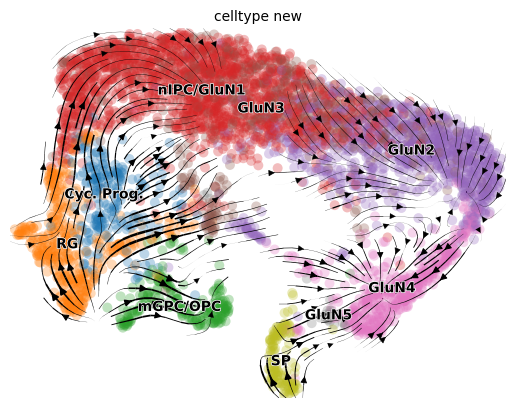

In [35]:
scv.pl.velocity_embedding_stream(adata_result, vkey='velo_s', color='celltype_new')

In [36]:
scv.tl.velocity_pseudotime(adata_result, vkey='velo_s')

computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


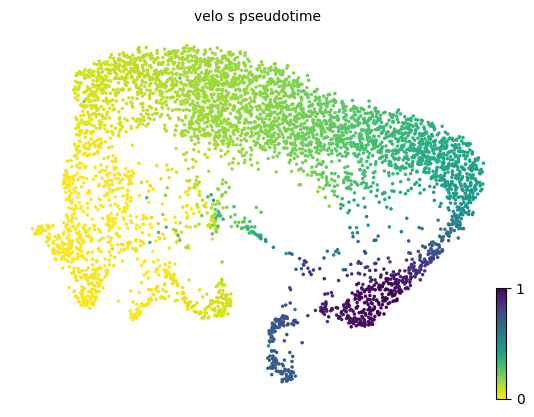

In [37]:
scv.pl.scatter(adata_result, color='velo_s_pseudotime')

In [39]:
adata_result.write_h5ad('data/Human_brain/adata_moflow.h5ad')